## Dependent Libaries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, accuracy_score

## Read Dataset

In [5]:
em_df=pd.read_csv(r"C:\Users\DELL\Desktop\work\Salaryemp.csv")

## View the Dataset

In [51]:
em_df.head(20)

,Years of Experience,Salary
0,5.0,90000
1,3.0,65000
2,15.0,150000
3,7.0,60000
4,20.0,200000
5,2.0,55000
6,12.0,120000
7,4.0,80000
8,1.0,45000
9,10.0,110000


## Understand the Dataset

In [7]:
em_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Years of Experience  324 non-null    float64
 1   Salary               324 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 5.2 KB


## Check Missing Values

In [8]:
em_df.isnull().sum()

Years of Experience    0
Salary                 0
dtype: int64

## Define Features (X) and Target (y)

In [9]:
X=em_df[['Years of Experience']] # Features, independent (x) 
y=em_df['Salary']                # Target, dependent (y)

## Split the Dataset

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape #80%, #features, #Training Data=== Teach the model

In [ ]:
X_test.shape #20%, #features ,#Testing Data=== Evaluate the model

In [ ]:
y_train.shape #Target 

In [ ]:
y_test.shape #Target 

## Create the Linear Regression Model

In [10]:
Model = LinearRegression()

## Train the Model

In [13]:
Model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Make Predictions

In [14]:
y_Prediction=Model.predict(X_test)

In [15]:
y_Prediction

array([113379.25443452, 127108.45183362,  58462.46483813,  99650.05703542,
        92785.45833588,  92785.45833588,  51597.86613858,  65327.06353768,
       175160.64273046,  41300.96808926,  44733.26743903, 120243.85313407,
        92785.45833588, 140837.64923272,  92785.45833588, 175160.64273046,
       113379.25443452, 133973.05053317,  51597.86613858,  44733.26743903,
        85920.85963633,  58462.46483813,  65327.06353768,  31004.07003993,
       202619.03752866,  79056.26093678, 133973.05053317, 168296.04403092,
       175160.64273046,  37868.66873948, 106514.65573497, 168296.04403092,
        99650.05703542, 154566.84663182, 133973.05053317,  41300.96808926,
        92785.45833588,  99650.05703542,  85920.85963633,  41300.96808926,
        99650.05703542,  51597.86613858, 113379.25443452,  58462.46483813,
        44733.26743903,  51597.86613858, 140837.64923272,  44733.26743903,
       147702.24793227,  79056.26093678, 182025.24143001,  44733.26743903,
        58462.46483813,  

## View Predictions

In [20]:
df = pd.DataFrame({
    'Actual Salary': y_test,
    'Predicted Salary': y_Prediction
})
df.head()

,Actual Salary,Predicted Salary
132,100000,113379.254435
108,100000,127108.451834
137,50000,58462.464838
9,110000,99650.057035
180,105000,92785.458336


In [24]:
df['Error']=df['Actual Salary'] - df['Predicted Salary']
df['ABS']=abs(df['Error'].mean())

In [25]:
round(df,2)

,Actual Salary,Predicted Salary,Error,ABS
132,100000,113379.25,-13379.25,333.78
108,100000,127108.45,-27108.45,333.78
137,50000,58462.46,-8462.46,333.78
9,110000,99650.06,10349.94,333.78
180,105000,92785.46,12214.54,333.78
...,...,...,...,...
104,80000,120243.85,-40243.85,333.78
231,85000,85920.86,-920.86,333.78
60,170000,188889.84,-18889.84,333.78
94,75000,79056.26,-4056.26,333.78


## Evaluate the Model

In [32]:
mae = mean_absolute_error(y_test, y_Prediction)
mse = mean_squared_error(y_test, y_Prediction)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_Prediction)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 11850.81040193959
MSE: 283179356.60890037
RMSE: 16827.93381876992
R2 Score: 0.850152763634785


## Coefficients

In [36]:
Model.coef_

array([6864.59869955])

In [34]:
Model.intercept_

np.float64(31004.07003993394)

## Visualize the Regression Line

<function matplotlib.pyplot.show(close=None, block=None)>

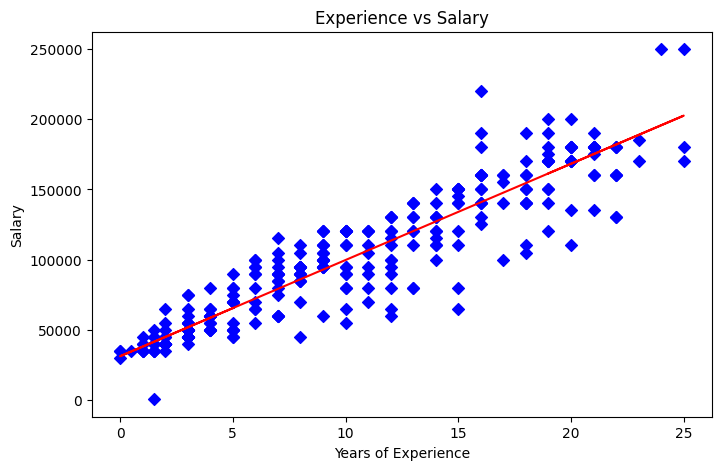

In [52]:
plt.figure(figsize=(8,5))

plt.scatter(X, y, c='blue', marker='D')
plt.plot(X, Model.predict(X), c='red')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Experience vs Salary')
plt.savefig("SalaryRegression.png")
plt.show

In [48]:
Model.predict([[15]])

C:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([133973.05053317])